In [1]:
!pip -q install kagglehub tensorflow scikit-learn matplotlib seaborn pillow

## 2. Imports and reproducibility


In [2]:
import os, random, glob, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import kagglehub
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers, metrics
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score, f1_score

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow:', tf.__version__)
print('GPU available:', bool(tf.config.list_physical_devices('GPU')))

gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception:
        pass

TensorFlow: 2.20.0
GPU available: True


## 3. Configuration

You can increase `EPOCHS_STAGE_1` and `EPOCHS_STAGE_2` for better final accuracy. The current values are safe for a normal project run.


In [3]:
DATASET_HANDLE = 'nih-chest-xrays/sample'
IMG_SIZE = 224
BATCH_SIZE = 32
VAL_SIZE = 0.15
TEST_SIZE = 0.15
MAX_IMAGES = None   # Use None for all 5,606 images. Example: set 1500 for a faster test run.

EPOCHS_STAGE_1 = 8     # frozen pretrained backbone
EPOCHS_STAGE_2 = 6     # fine-tuning last CNN layers
FINE_TUNE_LAST_N_LAYERS = 25

NORMAL_LABEL = 'No Finding'
AUTOTUNE = tf.data.AUTOTUNE

## 4. Download/load the dataset inside the notebook

This cell downloads the Kaggle public dataset directly. It also automatically finds the images folder and the dataset label file inside the downloaded dataset folder.


In [4]:
# Download dataset directly in the notebook
# In most Colab/Kaggle environments this works directly for public datasets.
dataset_dir = kagglehub.dataset_download(DATASET_HANDLE)
dataset_dir = Path(dataset_dir)
print('Dataset downloaded/found at:', dataset_dir)

# Find image files
image_extensions = ['*.png', '*.jpg', '*.jpeg']
image_paths = []
for ext in image_extensions:
    image_paths.extend(dataset_dir.rglob(ext))
image_paths = sorted(image_paths)
print('Number of image files found:', len(image_paths))

# Find labels file included with the dataset download, without requiring any manual CSV path
label_candidates = list(dataset_dir.rglob('*.csv'))
print('Label files found inside dataset:', [p.name for p in label_candidates])

if not label_candidates:
    raise FileNotFoundError('No label CSV was found inside the downloaded Kaggle dataset folder.')

# Prefer sample_labels.csv when present
labels_path = None
for p in label_candidates:
    if 'sample_labels' in p.name.lower():
        labels_path = p
        break
if labels_path is None:
    labels_path = label_candidates[0]

print('Using labels from downloaded dataset file:', labels_path.name)
labels_df = pd.read_csv(labels_path)
labels_df.head()

100%|██████████| 4.20G/4.20G [00:43<00:00, 104MB/s] 

Extracting files...


Dataset downloaded/found at: /root/.cache/kagglehub/datasets/nih-chest-xrays/sample/versions/4
Number of image files found: 11212
Label files found inside dataset: ['sample_labels.csv', 'sample_labels.csv']
Using labels from downloaded dataset file: sample_labels.csv


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImageWidth,OriginalImageHeight,OriginalImagePixelSpacing_x,OriginalImagePixelSpacing_y
0,00000013_005.png,Emphysema|Infiltration|Pleural_Thickening|Pneu...,5,13,060Y,M,AP,3056,2544,0.139,0.139
1,00000013_026.png,Cardiomegaly|Emphysema,26,13,057Y,M,AP,2500,2048,0.168,0.168
2,00000017_001.png,No Finding,1,17,077Y,M,AP,2500,2048,0.168,0.168
3,00000030_001.png,Atelectasis,1,30,079Y,M,PA,2992,2991,0.143,0.143
4,00000032_001.png,Cardiomegaly|Edema|Effusion,1,32,055Y,F,AP,2500,2048,0.168,0.168


In [5]:
# Detect required columns safely
possible_image_cols = ['Image Index', 'image', 'filename', 'FileName', 'Image']
possible_label_cols = ['Finding Labels', 'label', 'labels', 'Finding Label']

image_col = next((c for c in possible_image_cols if c in labels_df.columns), None)
label_col = next((c for c in possible_label_cols if c in labels_df.columns), None)

if image_col is None or label_col is None:
    raise ValueError(f'Could not detect image/label columns. Columns found: {labels_df.columns.tolist()}')

# Map filename to actual downloaded image path
path_map = {p.name: str(p) for p in image_paths}

df = labels_df[[image_col, label_col]].copy()
df.columns = ['filename', 'finding_labels']
df['filepath'] = df['filename'].map(path_map)
df = df.dropna(subset=['filepath']).reset_index(drop=True)

df['label'] = (df['finding_labels'].astype(str) != NORMAL_LABEL).astype(int)
df['class_name'] = df['label'].map({0: 'No Finding', 1: 'Disease'})

if MAX_IMAGES is not None and MAX_IMAGES < len(df):
    df, _ = train_test_split(df, train_size=MAX_IMAGES, stratify=df['label'], random_state=SEED)
    df = df.reset_index(drop=True)

print('Final usable images:', len(df))
print(df['class_name'].value_counts())
df.head()

Final usable images: 5606
class_name
No Finding    3044
Disease       2562
Name: count, dtype: int64


,filename,finding_labels,filepath,label,class_name
0,00000013_005.png,Emphysema|Infiltration|Pleural_Thickening|Pneu...,/root/.cache/kagglehub/datasets/nih-chest-xray...,1,Disease
1,00000013_026.png,Cardiomegaly|Emphysema,/root/.cache/kagglehub/datasets/nih-chest-xray...,1,Disease
2,00000017_001.png,No Finding,/root/.cache/kagglehub/datasets/nih-chest-xray...,0,No Finding
3,00000030_001.png,Atelectasis,/root/.cache/kagglehub/datasets/nih-chest-xray...,1,Disease
4,00000032_001.png,Cardiomegaly|Edema|Effusion,/root/.cache/kagglehub/datasets/nih-chest-xray...,1,Disease


## 6. Visualize class distribution and sample images


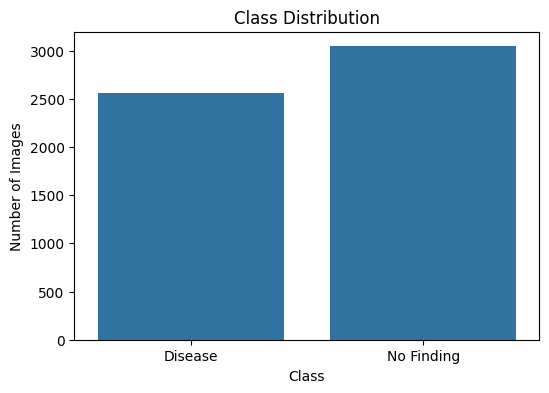

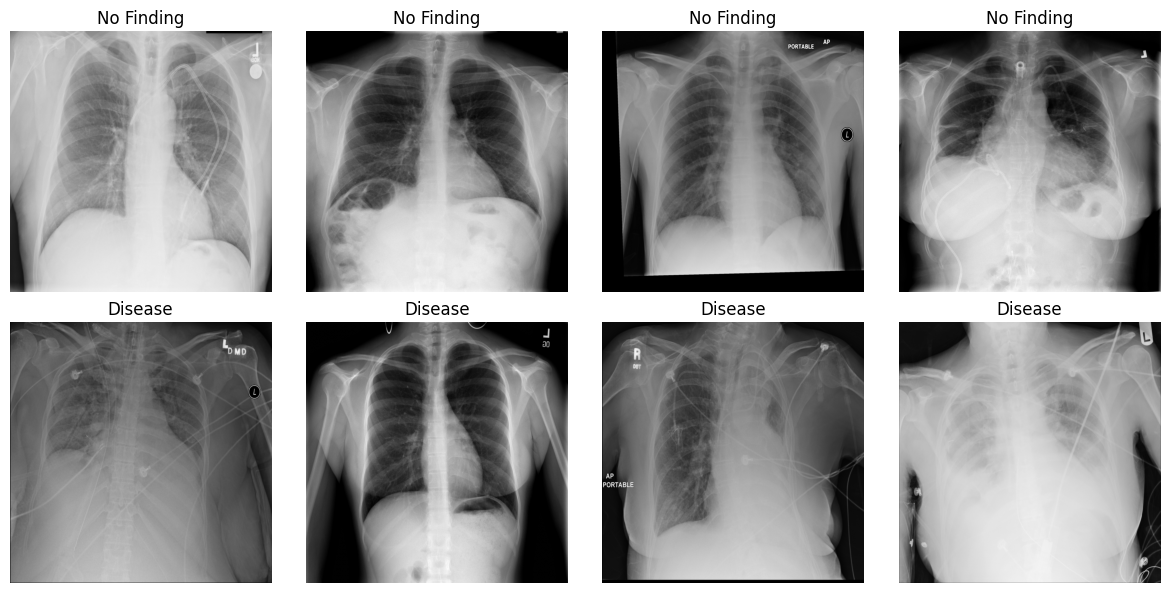

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='class_name')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.show()

sample_df = df.groupby('label', group_keys=False).apply(lambda x: x.sample(min(4, len(x)), random_state=SEED))
plt.figure(figsize=(12,6))
for i, (_, row) in enumerate(sample_df.iterrows(), start=1):
    img = Image.open(row['filepath']).convert('L')
    plt.subplot(2,4,i)
    plt.imshow(img, cmap='gray')
    plt.title(row['class_name'])
    plt.axis('off')
plt.tight_layout()
plt.show()

## 7. Train/validation/test split


In [8]:
train_df, test_df = train_test_split(
    df, test_size=TEST_SIZE, stratify=df['label'], random_state=SEED
)

relative_val = VAL_SIZE / (1 - TEST_SIZE)
train_df, val_df = train_test_split(
    train_df, test_size=relative_val, stratify=train_df['label'], random_state=SEED
)

print(f'Train: {len(train_df)}')
print(f'Validation: {len(val_df)}')
print(f'Test: {len(test_df)}')
print('Train class distribution:')
print(train_df['class_name'].value_counts())

Train: 3924
Validation: 841
Test: 841
Train class distribution:
class_name
No Finding    2130
Disease       1794
Name: count, dtype: int64


## 8. TensorFlow data pipeline

The model receives grayscale chest X-rays converted to RGB because the pretrained EfficientNet backbone expects 3 channels.


In [9]:
def load_image(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32)
    img = preprocess_input(img)
    return img, tf.cast(label, tf.float32)

# Data augmentation for training only
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.04),
    layers.RandomZoom(0.08),
    layers.RandomContrast(0.10),
], name='xray_augmentation')

def add_augmentation(img, label):
    return data_augmentation(img, training=True), label

def make_dataset(dataframe, training=False):
    filepaths = dataframe['filepath'].astype(str).values
    labels = dataframe['label'].astype('float32').values
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(add_augmentation, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)
test_ds = make_dataset(test_df, training=False)

# Class weights help because chest X-ray classes are usually imbalanced
classes = np.array([0, 1])
weights = compute_class_weight(class_weight='balanced', classes=classes, y=train_df['label'].values)
class_weights = {int(c): float(w) for c, w in zip(classes, weights)}
print('Class weights:', class_weights)

Class weights: {0: 0.9211267605633803, 1: 1.0936454849498327}


## 9. Model builder: pretrained CNN + sequence head

Why this is suitable for RNN/GRU on images:

1. EfficientNet extracts a spatial feature map from each X-ray.
2. The feature map is reshaped into a sequence of visual patches.
3. RNN/GRU learns relationships between these visual patch features.
4. The CNN backbone is fine-tuned, so the model is not trained from scratch.


In [10]:
def build_cnn_sequence_model(sequence_layer='gru'):
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='xray_input')

    backbone = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_tensor=inputs
    )
    backbone.trainable = False

    x = backbone.output                     # shape: H x W x C
    x = layers.Conv2D(256, 1, padding='same', activation='relu', name='channel_reduction')(x)
    x = layers.BatchNormalization()(x)

    # Convert feature map into sequence: (batch, H*W, channels)
    h, w, c = x.shape[1], x.shape[2], x.shape[3]
    x = layers.Reshape((h * w, c), name='feature_map_to_sequence')(x)

    if sequence_layer.lower() == 'rnn':
        x = layers.Bidirectional(
            layers.SimpleRNN(128, return_sequences=True, dropout=0.25),
            name='bidirectional_simple_rnn'
        )(x)
    elif sequence_layer.lower() == 'gru':
        x = layers.Bidirectional(
            layers.GRU(128, return_sequences=True, dropout=0.25),
            name='bidirectional_gru'
        )(x)
    else:
        raise ValueError("sequence_layer must be 'rnn' or 'gru'")

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.45)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.30)(x)
    outputs = layers.Dense(1, activation='sigmoid', name='disease_probability')(x)

    model = models.Model(inputs, outputs, name=f'EfficientNetB0_Bi{sequence_layer.upper()}')
    return model, backbone

def compile_model(model, learning_rate=1e-4):
    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            metrics.Precision(name='precision'),
            metrics.Recall(name='recall'),
            metrics.AUC(name='auc')
        ]
    )
    return model

## 10. Training helper with two-stage fine-tuning

Stage 1 freezes the pretrained CNN backbone.  
Stage 2 unfreezes only the last CNN layers and continues training with a smaller learning rate.


In [13]:
def get_callbacks(model_name):
    return [
        callbacks.ModelCheckpoint(
            filepath=f'best_{model_name}.keras',
            monitor='val_auc',
            mode='max',
            save_best_only=True,
            verbose=1
        ),
        callbacks.EarlyStopping(
            monitor='val_auc',
            mode='max',
            patience=4,
            restore_best_weights=True,
            verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.3,
            patience=2,
            min_lr=1e-7,
            verbose=1
        )
    ]

def fine_tune_last_layers(backbone, last_n=25):
    backbone.trainable = True
    for layer in backbone.layers[:-last_n]:
        layer.trainable = False
    # Keep BatchNorm stable during fine-tuning on small medical dataset
    for layer in backbone.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

def train_two_stage(sequence_layer):
    model_name = f'{sequence_layer}_nih_xray'
    model, backbone = build_cnn_sequence_model(sequence_layer)
    compile_model(model, learning_rate=1e-4)
    print(model.summary())

    print(f'===== Stage 1: train {sequence_layer.upper()} head with frozen EfficientNet =====')
    history1 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_STAGE_1,
        class_weight=class_weights,
        callbacks=get_callbacks(model_name + '_stage1')
    )

    print(f'===== Stage 2: fine-tune last {FINE_TUNE_LAST_N_LAYERS} EfficientNet layers =====')
    fine_tune_last_layers(backbone, FINE_TUNE_LAST_N_LAYERS)
    compile_model(model, learning_rate=1e-5)
    history2 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_STAGE_2,
        class_weight=class_weights,
        callbacks=get_callbacks(model_name + '_finetuned')
    )

    return model, history1, history2

## 11. Train the RNN model


In [14]:
rnn_model, rnn_history1, rnn_history2 = train_two_stage('rnn')

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "EfficientNetB0_BiRNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ xray_input          │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ xray_input[0][0]  │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,518,820 (17.24 MB)

 Trainable params: 468,481 (1.79 MB)

 Non-trainable params: 4,050,339 (15.45 MB)

None
===== Stage 1: train RNN head with frozen EfficientNet =====
Epoch 1/8
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 782ms/step - accuracy: 0.5393 - auc: 0.5579 - loss: 0.9056 - precision: 0.5010 - recall: 0.4853
Epoch 1: val_auc improved from None to 0.62704, saving model to best_rnn_nih_xray_stage1.keras

Epoch 1: finished saving model to best_rnn_nih_xray_stage1.keras
123/123 ━━━━━━━━━━━━━━━━━━━━ 165s 1s/step - accuracy: 0.5522 - auc: 0.5695 - loss: 0.8931 - precision: 0.5103 - recall: 0.5123 - val_accuracy: 0.5922 - val_auc: 0.6270 - val_loss: 0.6746 - val_precision: 0.5445 - val_recall: 0.6536 - learning_rate: 1.0000e-04
Epoch 2/8
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 663ms/step - accuracy: 0.5595 - auc: 0.5768 - loss: 0.8686 - precision: 0.5233 - recall: 0.5379
Epoch 2: val_auc improved from 0.62704 to 0.64960, saving model to best_rnn_nih_xray_stage1.keras

Epoch 2: finished saving model to best_rnn_nih_xray_stage1.keras
123/123 ━━━━━━━━━━━━━━━━━━━━ 142s 743ms/step - accuracy: 0.5688 - auc: 0.

## 12. Train the GRU model


In [15]:
gru_model, gru_history1, gru_history2 = train_two_stage('gru')

Model: "EfficientNetB0_BiGRU"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ xray_input          │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ xray_input[0][0]  │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 224, 224,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 224, 224,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,716,708 (17.99 MB)

 Trainable params: 666,369 (2.54 MB)

 Non-trainable params: 4,050,339 (15.45 MB)

None
===== Stage 1: train GRU head with frozen EfficientNet =====
Epoch 1/8
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 639ms/step - accuracy: 0.5207 - auc: 0.5330 - loss: 0.9244 - precision: 0.4743 - recall: 0.4487
Epoch 1: val_auc improved from None to 0.63498, saving model to best_gru_nih_xray_stage1.keras

Epoch 1: finished saving model to best_gru_nih_xray_stage1.keras
123/123 ━━━━━━━━━━━━━━━━━━━━ 115s 755ms/step - accuracy: 0.5433 - auc: 0.5574 - loss: 0.8929 - precision: 0.5006 - recall: 0.4833 - val_accuracy: 0.6100 - val_auc: 0.6350 - val_loss: 0.6666 - val_precision: 0.5959 - val_recall: 0.4531 - learning_rate: 1.0000e-04
Epoch 2/8
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 682ms/step - accuracy: 0.5723 - auc: 0.5916 - loss: 0.8464 - precision: 0.5107 - recall: 0.5080
Epoch 2: val_auc improved from 0.63498 to 0.66521, saving model to best_gru_nih_xray_stage1.keras

Epoch 2: finished saving model to best_gru_nih_xray_stage1.keras
123/123 ━━━━━━━━━━━━━━━━━━━━ 134s 762ms/step - accuracy: 0.5652 - auc:

## 13. Evaluation helper


In [16]:
def evaluate_model(model, name):
    y_true = test_df['label'].values.astype(int)
    y_prob = model.predict(test_ds).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc_value = roc_auc_score(y_true, y_prob)

    print(f'{name} Results')
    print('-' * 50)
    print(f'Accuracy: {acc:.4f}')
    print(f'F1-score: {f1:.4f}')
    print(f'AUC     : {auc_value:.4f}')
    print('Classification Report:')
    print(classification_report(y_true, y_pred, target_names=['No Finding', 'Disease']))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Finding','Disease'], yticklabels=['No Finding','Disease'])
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f'AUC = {auc_value:.3f}')
    plt.plot([0,1], [0,1], linestyle='--')
    plt.title(f'{name} ROC Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    return {'Model': name, 'Accuracy': acc, 'F1': f1, 'AUC': auc_value}

## 14. Evaluate RNN and GRU


27/27 ━━━━━━━━━━━━━━━━━━━━ 9s 332ms/step
Fine-tuned EfficientNet + BiRNN Results
--------------------------------------------------
Accuracy: 0.6433
F1-score: 0.6667
AUC     : 0.7158
Classification Report:
              precision    recall  f1-score   support

  No Finding       0.74      0.53      0.62       457
     Disease       0.58      0.78      0.67       384

    accuracy                           0.64       841
   macro avg       0.66      0.65      0.64       841
weighted avg       0.67      0.64      0.64       841



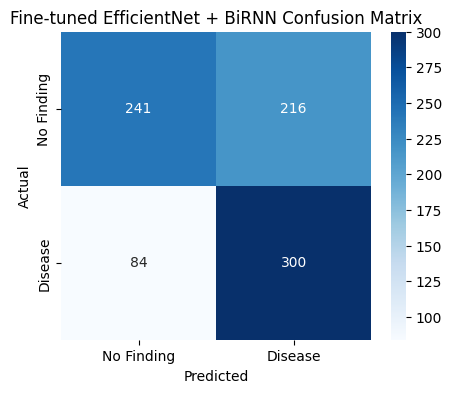

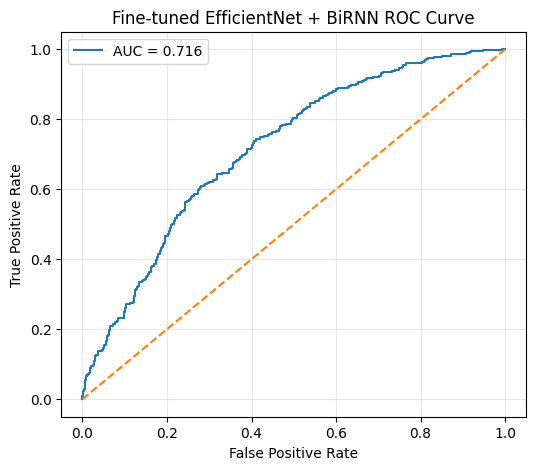

27/27 ━━━━━━━━━━━━━━━━━━━━ 8s 302ms/step
Fine-tuned EfficientNet + BiGRU Results
--------------------------------------------------
Accuracy: 0.6195
F1-score: 0.6687
AUC     : 0.6923
Classification Report:
              precision    recall  f1-score   support

  No Finding       0.76      0.43      0.55       457
     Disease       0.55      0.84      0.67       384

    accuracy                           0.62       841
   macro avg       0.66      0.64      0.61       841
weighted avg       0.67      0.62      0.61       841



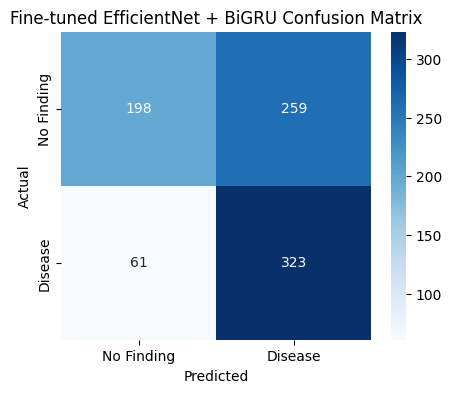

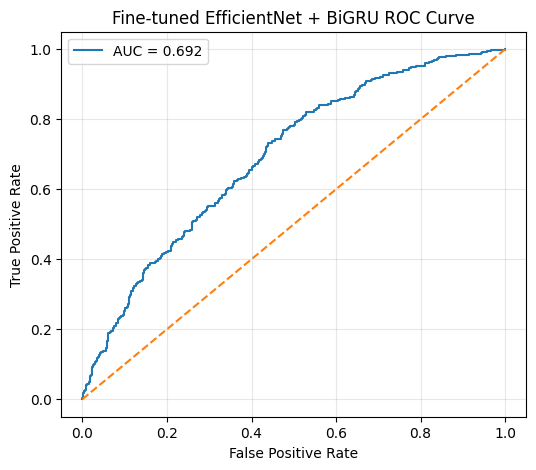

,Model,Accuracy,F1,AUC
0,Fine-tuned EfficientNet + BiRNN,0.643282,0.666667,0.715810
1,Fine-tuned EfficientNet + BiGRU,0.619501,0.668737,0.692292


In [23]:
rnn_results = evaluate_model(rnn_model, 'Fine-tuned EfficientNet + BiRNN')
gru_results = evaluate_model(gru_model, 'Fine-tuned EfficientNet + BiGRU')

results_df = pd.DataFrame([rnn_results, gru_results])
results_df

## 15. Training curves


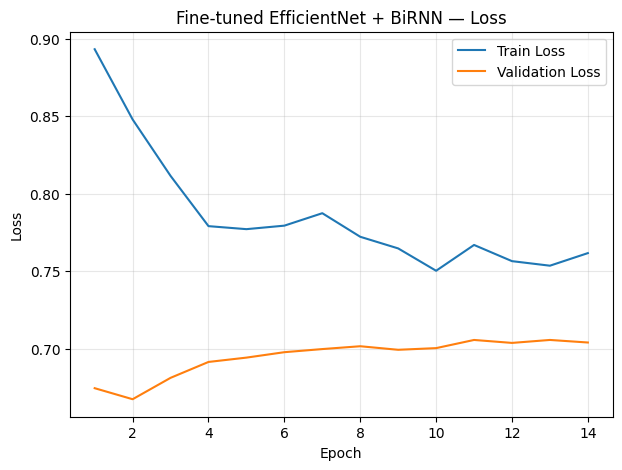

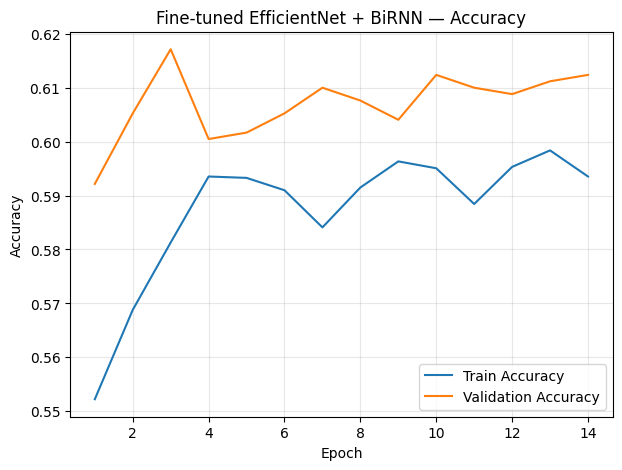

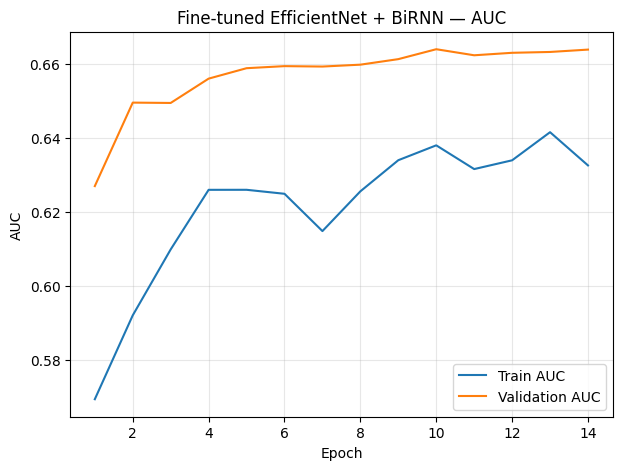

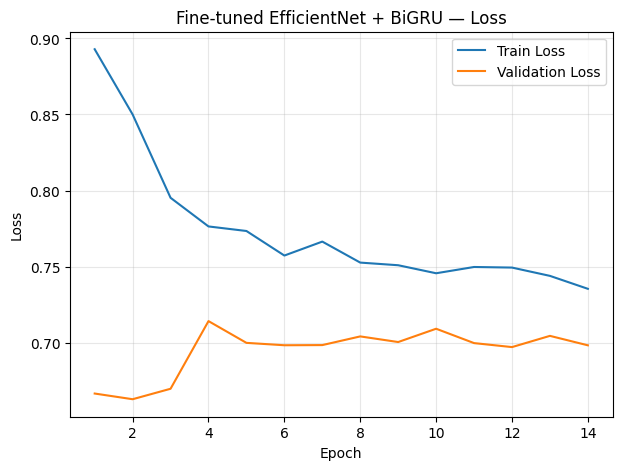

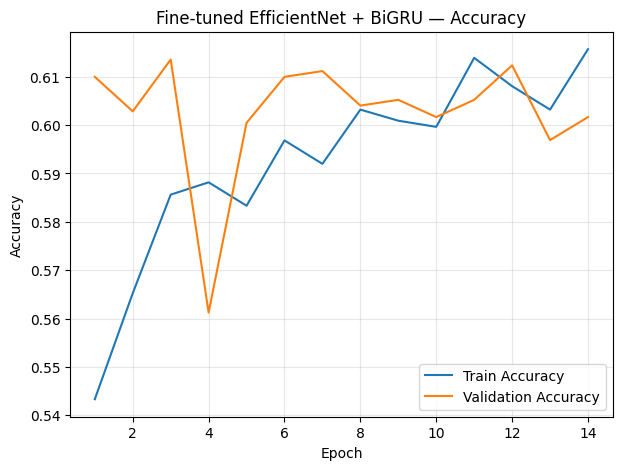

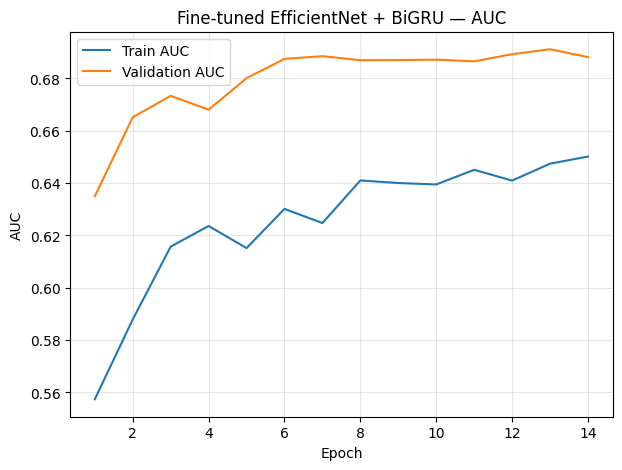

In [24]:
def merge_histories(h1, h2):
    merged = {}
    keys = set(h1.history.keys()).union(set(h2.history.keys()))
    for k in keys:
        merged[k] = h1.history.get(k, []) + h2.history.get(k, [])
    return merged

def plot_history(h1, h2, title):
    hist = merge_histories(h1, h2)
    epochs = range(1, len(hist['loss']) + 1)

    plt.figure(figsize=(7,5))
    plt.plot(epochs, hist['loss'], label='Train Loss')
    plt.plot(epochs, hist['val_loss'], label='Validation Loss')
    plt.title(title + ' — Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    plt.figure(figsize=(7,5))
    plt.plot(epochs, hist['accuracy'], label='Train Accuracy')
    plt.plot(epochs, hist['val_accuracy'], label='Validation Accuracy')
    plt.title(title + ' — Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    plt.figure(figsize=(7,5))
    plt.plot(epochs, hist['auc'], label='Train AUC')
    plt.plot(epochs, hist['val_auc'], label='Validation AUC')
    plt.title(title + ' — AUC')
    plt.xlabel('Epoch')
    plt.ylabel('AUC')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

plot_history(rnn_history1, rnn_history2, 'Fine-tuned EfficientNet + BiRNN')
plot_history(gru_history1, gru_history2, 'Fine-tuned EfficientNet + BiGRU')

## 16. Final comparison and save outputs


,Model,Accuracy,F1,AUC
0,Fine-tuned EfficientNet + BiRNN,0.643282,0.666667,0.715810
1,Fine-tuned EfficientNet + BiGRU,0.619501,0.668737,0.692292


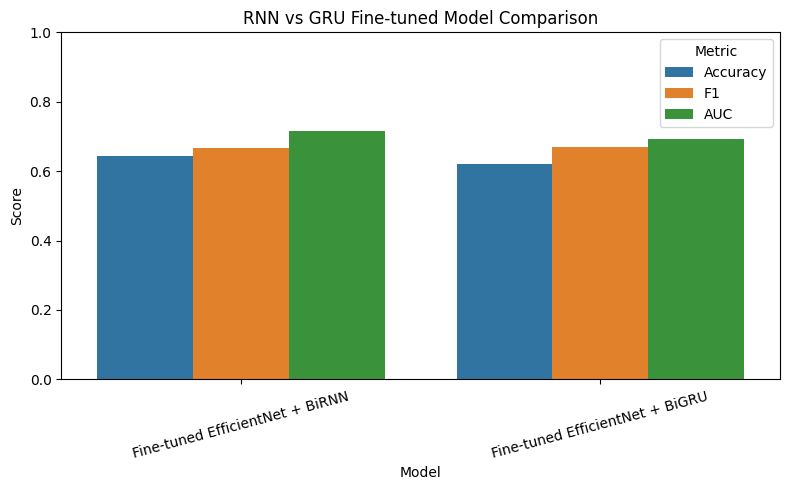

Saved files:
- phase3_nih_xray_rnn_gru_results.csv
- phase3_nih_xray_rnn_finetuned.keras
- phase3_nih_xray_gru_finetuned.keras
- best_rnn_nih_xray_stage1.keras / best_rnn_nih_xray_finetuned.keras
- best_gru_nih_xray_stage1.keras / best_gru_nih_xray_finetuned.keras


In [25]:
results_df = results_df.sort_values(by='AUC', ascending=False).reset_index(drop=True)
display(results_df)

plt.figure(figsize=(8,5))
sns.barplot(data=results_df.melt(id_vars='Model', value_vars=['Accuracy','F1','AUC']), x='Model', y='value', hue='variable')
plt.title('RNN vs GRU Fine-tuned Model Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

results_df.to_csv('phase3_nih_xray_rnn_gru_results.csv', index=False)
rnn_model.save('phase3_nih_xray_rnn_finetuned.keras')
gru_model.save('phase3_nih_xray_gru_finetuned.keras')

print('Saved files:')
print('- phase3_nih_xray_rnn_gru_results.csv')
print('- phase3_nih_xray_rnn_finetuned.keras')
print('- phase3_nih_xray_gru_finetuned.keras')
print('- best_rnn_nih_xray_stage1.keras / best_rnn_nih_xray_finetuned.keras')
print('- best_gru_nih_xray_stage1.keras / best_gru_nih_xray_finetuned.keras')